In [ ]:
import marimo as mo

# Pivot and Unpivot

Using the emp_compensation table, create a pivot of the table focusing on the salary_component_type after creating the pivot table, use that table to unpivot back to the original table.

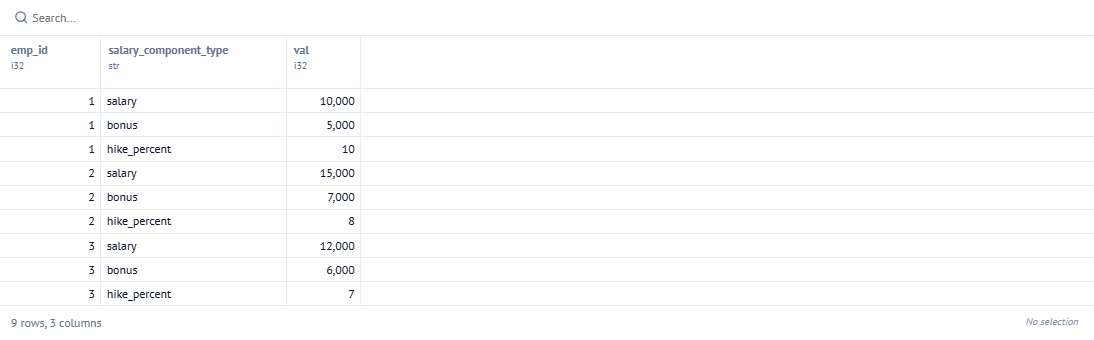

In [ ]:
_df = mo.sql(
    f"""
    DROP TABLE IF EXISTS emp_compensation;

    CREATE TABLE emp_compensation (
    	emp_id INT,
    	salary_component_type VARCHAR(20),
    	val INT
    );

    INSERT INTO
    	emp_compensation
    VALUES
    	(1, 'salary', 10000),
    	(1, 'bonus', 5000),
    	(1, 'hike_percent', 10),
    	(2, 'salary', 15000),
    	(2, 'bonus', 7000),
    	(2, 'hike_percent', 8),
    	(3, 'salary', 12000),
    	(3, 'bonus', 6000),
    	(3, 'hike_percent', 7);

    SELECT * FROM emp_compensation;
    """
)

# Solution - Pivot

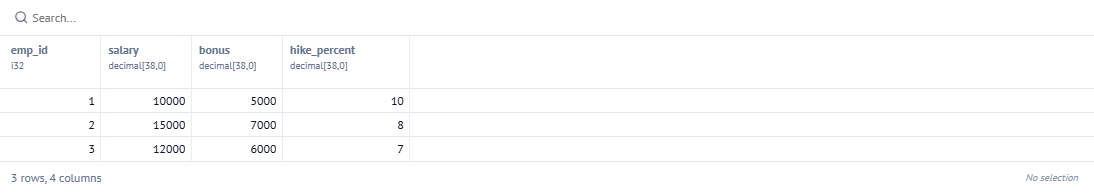

In [ ]:
_df = mo.sql(
    f"""
    CREATE OR REPLACE VIEW emp_compensation_pivot AS
    SELECT
    	emp_id,
    	SUM(
    		CASE
    			WHEN salary_component_type ILIKE 'salary' THEN val
    		END
    	) AS salary,
    	SUM(
    		CASE
    			WHEN salary_component_type ILIKE 'bonus' THEN val
    		END
    	) AS bonus,
    	SUM(
    		CASE
    			WHEN salary_component_type ILIKE 'hike_percent' THEN val
    		END
    	) AS hike_percent
    FROM
    	emp_compensation
    GROUP BY
    	emp_id
    ORDER BY
    	emp_id;

    SELECT
    	*
    FROM
    	emp_compensation_pivot;
    """
)

# Solution - Unpivot

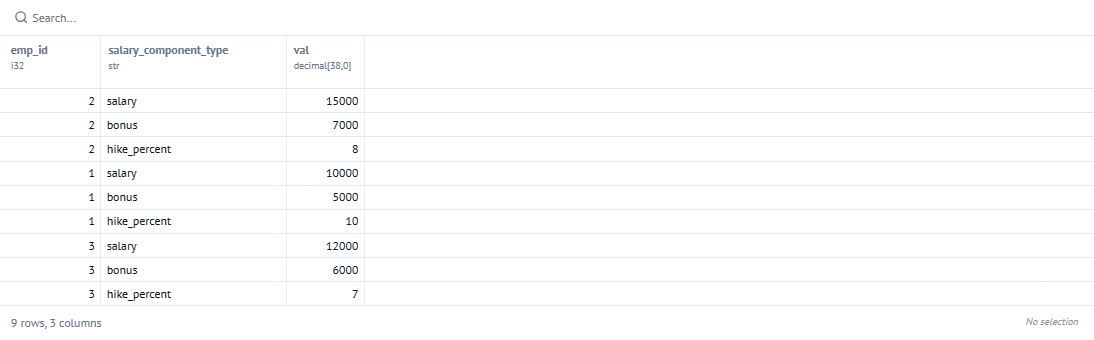

In [ ]:
_df = mo.sql(
    f"""
    -- 1. Using the Cross Join Lateral method - best way, performs single scan of the table.
    SELECT
    	e.emp_id,
    	v.salary_component_type,
    	v.val
    FROM
    	emp_compensation_pivot AS e
    	CROSS JOIN LATERAL (
    		VALUES
    			('salary', e.salary),
    			('bonus', e.bonus),
    			('hike_percent', e.hike_percent)
    	) AS v (salary_component_type, val)
    """
)

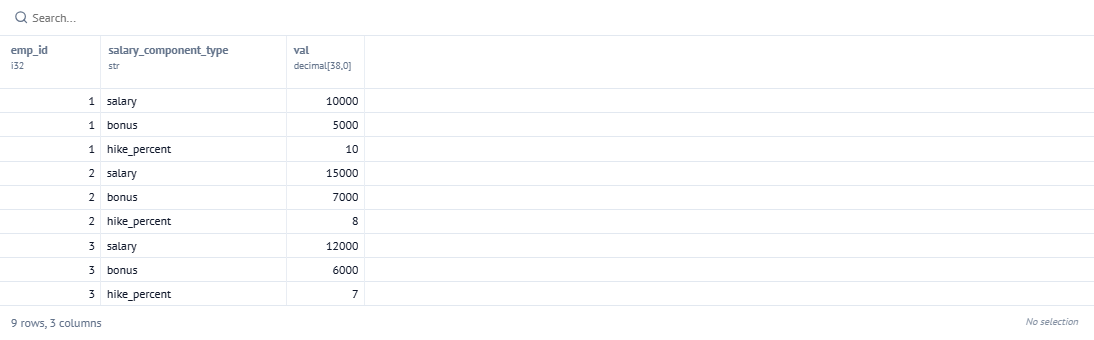

In [ ]:
_df = mo.sql(
    f"""
    -- 2. Using the filter and union all method - second best way, performs multi scan.
    select
    	emp_id,
    	'salary' as salary_component_type,
    	salary as val
    from emp_compensation_pivot
    union all
    select
    	emp_id,
    	'bonus' as salary_component_type,
    	bonus as val
    from emp_compensation_pivot
    union all
    select
    	emp_id,
    	'hike_percent' as salary_component_type,
    	hike_percent as val
    from emp_compensation_pivot
    order by 1;
    """
)